    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

C:\Users\ayush\AppData\Local\Temp\ipykernel_620\2298708028.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Gender'].fillna(data['Gender'].mode()[0], inplace=True)
C:\Users\ayush\AppData\Local\Temp\ipykernel_620\2298708028.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

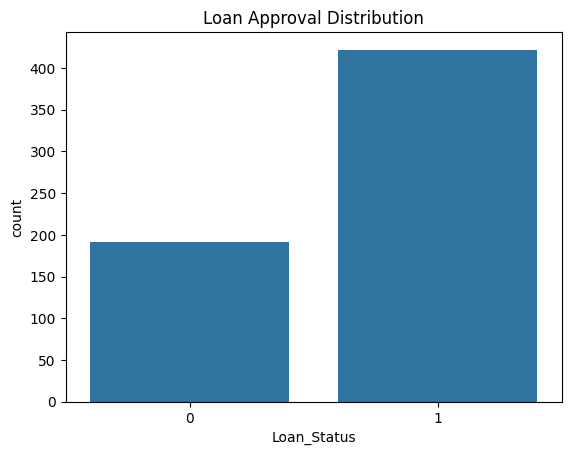

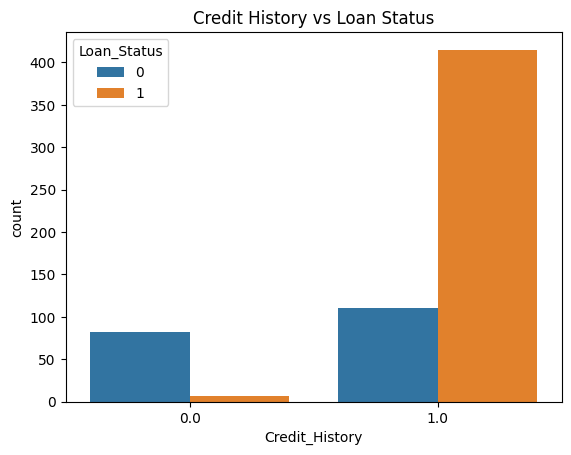

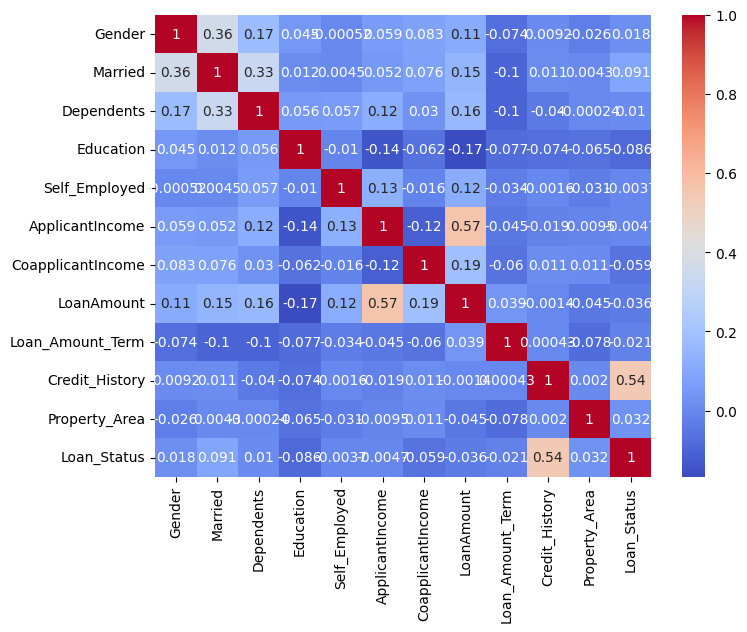

C:\Users\ayush\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\ayush\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also re


Logistic Regression
Accuracy : 0.7886178861788617
Precision: 0.7596153846153846
Recall   : 0.9875
F1 Score : 0.8586956521739131
ROC-AUC  : 0.7479651162790698
K-Fold Scores: [0.81300813 0.77235772 0.7804878  0.85365854 0.81147541]
Mean CV Score: 0.8061975209916034

Decision Tree
Accuracy : 0.6991869918699187
Precision: 0.7529411764705882
Recall   : 0.8
F1 Score : 0.7757575757575758
ROC-AUC  : 0.6558139534883721
K-Fold Scores: [0.68292683 0.67479675 0.72357724 0.75609756 0.7295082 ]
Mean CV Score: 0.7133813141410104

Random Forest
Accuracy : 0.7723577235772358
Precision: 0.7549019607843137
Recall   : 0.9625
F1 Score : 0.8461538461538461
ROC-AUC  : 0.7600290697674419
K-Fold Scores: [0.78861789 0.7398374  0.77235772 0.81300813 0.80327869]
Mean CV Score: 0.7834199653471945

SVM
Accuracy : 0.6504065040650406
Precision: 0.6504065040650406
Recall   : 1.0
F1 Score : 0.7881773399014779
ROC-AUC  : 0.45290697674418606
K-Fold Scores: [0.69105691 0.69105691 0.68292683 0.68292683 0.68852459]
Mean CV

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
data = pd.read_csv("loan.csv")

print(data.head())
print(data.info())

# Drop unnecessary column
data.drop('Loan_ID', axis=1, inplace=True)

# Handle

data['Gender'].fillna(data['Gender'].mode()[0], inplace=True)
data['Married'].fillna(data['Married'].mode()[0], inplace=True)
data['Dependents'].fillna(data['Dependents'].mode()[0], inplace=True)
data['Self_Employed'].fillna(data['Self_Employed'].mode()[0], inplace=True)

data['LoanAmount'].fillna(data['LoanAmount'].mean(), inplace=True)
data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mean(), inplace=True)
data['Credit_History'].fillna(data['Credit_History'].mode()[0], inplace=True)

# Encode categorial data
le = LabelEncoder()

cols = ['Gender','Married','Dependents','Education',
        'Self_Employed','Property_Area','Loan_Status']

for col in cols:
    data[col] = le.fit_transform(data[col])
#EDA

sns.countplot(x='Loan_Status', data=data)
plt.title("Loan Approval Distribution")
plt.show()

sns.countplot(x='Credit_History', hue='Loan_Status', data=data)
plt.title("Credit History vs Loan Status")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()
#featuring & Target

X = data.drop('Loan_Status', axis=1)
y = data['Loan_Status']

#train test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Model

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

#train + Evaluate

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("\n====================")
    print(name)
    print("====================")

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))

    # ROC AUC
    y_prob = model.predict_proba(X_test)[:,1]
    print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

    # K-Fold Cross Validation
    scores = cross_val_score(model, X, y, cv=5)
    print("K-Fold Scores:", scores)
    print("Mean CV Score:", scores.mean())